# Heston Stochastic Local Volatility: Calibration and Simulation

Full pipeline: SPX market data → SSVI surface → Heston base → SLV leverage function → Monte Carlo paths → smile verification.

Uses {cite:t}`VanDerStoep2014` for the LSV framework and {cite:t}`Gatheral2014` for SSVI. SSVI calibration details and arbitrage checks are in the [previous chapter](02_ssvi.ipynb) — here we just build the surface and move on to the SLV part.

In [1]:
import time
from pathlib import Path

import cppfm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from vol_data import load_latest_snapshot, fetch_spx_options, prepare_otm_slices

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['text.usetex'] = False

## Market Data & SSVI Surface

In [2]:
r = 0.04  # approximate risk-free rate
SNAPSHOT_DIR = Path('snapshots')

try:
    S0, df = load_latest_snapshot(SNAPSHOT_DIR)
except FileNotFoundError:
    print("No snapshot found — fetching live...")
    S0, df = fetch_spx_options("^SPX")

print(f"S0 = {S0:.2f}")
print(f"Total rows: {len(df)}")
df.head(3)

Loaded snapshot: spx_options_20260303_155315.csv  (fetched 20260303_155315)
S0 = 6730.42
Total rows: 16655


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,optionType,expiration,T,mid
0,SPXW260303C02800000,2026-03-03 15:11:06+00:00,2800.0,3936.00,3911.1,3927.4,-100.80005,-2.497029,1.0,0,0.00001,True,REGULAR,USD,call,2026-03-03,-0.001926,3919.25
1,SPXW260303C04400000,2026-03-02 16:17:47+00:00,4400.0,2465.38,2309.7,2325.9,0.00000,0.000000,1.0,1,0.00001,True,REGULAR,USD,call,2026-03-03,-0.001926,2317.80
2,SPXW260303C05400000,2026-03-02 15:31:59+00:00,5400.0,1448.59,1311.6,1327.4,0.00000,0.000000,4.0,4,0.00001,True,REGULAR,USD,call,2026-03-03,-0.001926,1319.50


In [3]:
slices = prepare_otm_slices(df, S0, r)
print(f"{len(slices)} maturity slices, T in [{slices[0]['T']:.3f}, {slices[-1]['T']:.3f}]")

40 maturity slices, T in [0.023, 1.789]


In [4]:
strikes_per_mat = [s['strikes'].tolist() for s in slices]
vols_per_mat    = [s['ivs'].tolist()     for s in slices]
forwards        = [float(s['F'])         for s in slices]
maturities      = [float(s['T'])         for s in slices]

opts = cppfm.SsviCalibrationOptions()
opts.lm_opts.max_iter = 100

ssvi = cppfm.calibrate_ssvi(strikes_per_mat, vols_per_mat, forwards, maturities, opts)
p = ssvi.params

print(f"rho={p.rho:.4f}  eta={p.eta:.4f}  gamma={p.gamma:.4f}")
print(f"RMSE={ssvi.rmse:.5f}  converged={ssvi.converged}")

surface = ssvi.build_analytical_surface(forwards)

rho=-0.3409  eta=0.6466  gamma=0.7019
RMSE=0.00318  converged=True


## Heston Base Calibration

Calibrate Heston $(v_0, \kappa, \bar{v}, \xi, \rho)$ to the SSVI surface. We sample the surface on a moneyness grid, then minimize weighted IV errors.

In [5]:
# Heston can't fit steep short-dated smiles — use T > 0.1 with ~8-10 slices
# the leverage function handles the residual
heston_slices = [s for s in slices if s['T'] > 0.1]
heston_slices = heston_slices[::max(1, len(heston_slices) // 10)]  # subsample if too many

slices_heston = []
for s in heston_slices:
    hsd = cppfm.HestonSliceData()
    hsd.T = s['T']
    hsd.strikes = s['strikes'].tolist()
    hsd.market_ivs = [surface.implied_volatility(K, s['T']) for K in s['strikes']]
    slices_heston.append(hsd)

print(f"Calibrating on {sum(len(s.strikes) for s in slices_heston)} (K,T) points across {len(slices_heston)} maturities")
print(f"T range: [{heston_slices[0]['T']:.3f}, {heston_slices[-1]['T']:.3f}]")

Calibrating on 1906 (K,T) points across 11 maturities
T range: [0.102, 1.288]


In [6]:
guess = cppfm.HestonParams(v0=0.05, kappa=1.5, vbar=0.05, sigma_v=0.4, rho=-0.7)

result = cppfm.calibrate_heston(slices_heston, S0=S0, r=r, guess=guess)
p = result.params
v0, kappa, vbar, xi, rho_h = p.v0, p.kappa, p.vbar, p.sigma_v, p.rho

print(f"C++ LM: {result.iterations} iters  RMSE={result.rmse:.2e}  converged={result.converged}")
print(f"v0={v0:.4f}  κ={kappa:.3f}  v̄={vbar:.4f}  ξ={xi:.3f}  ρ={rho_h:.3f}")
print(f"Feller: 2κv̄={2*kappa*vbar:.4f} vs ξ²={xi**2:.4f}  → {'OK' if 2*kappa*vbar > xi**2 else 'VIOLATED'}")

C++ LM: 19 iters  RMSE=5.14e-03  converged=True
v0=0.0843  κ=11.596  v̄=0.0501  ξ=4.438  ρ=-0.453
Feller: 2κv̄=1.1622 vs ξ²=19.6943  → VIOLATED


Feller violated — expected with real skew data. $\xi^2 \gg 2\kappa\bar{v}$ means variance hits zero regularly. Simulation uses full truncation; the leverage function absorbs the residual smile error that Heston alone can't capture.

WARNING [HestonModel]: Feller condition NOT satisfied!
  Required: 2*κ*v̄ ≥ σ²_v
  Current:  2*11.5956*0.0501148 = 1.16222 < σ²_v = 19.6943
  Implication: Variance process can reach zero.
  Use appropriate discretization schemes (BK/QE, BK/TG) that handle V->0.



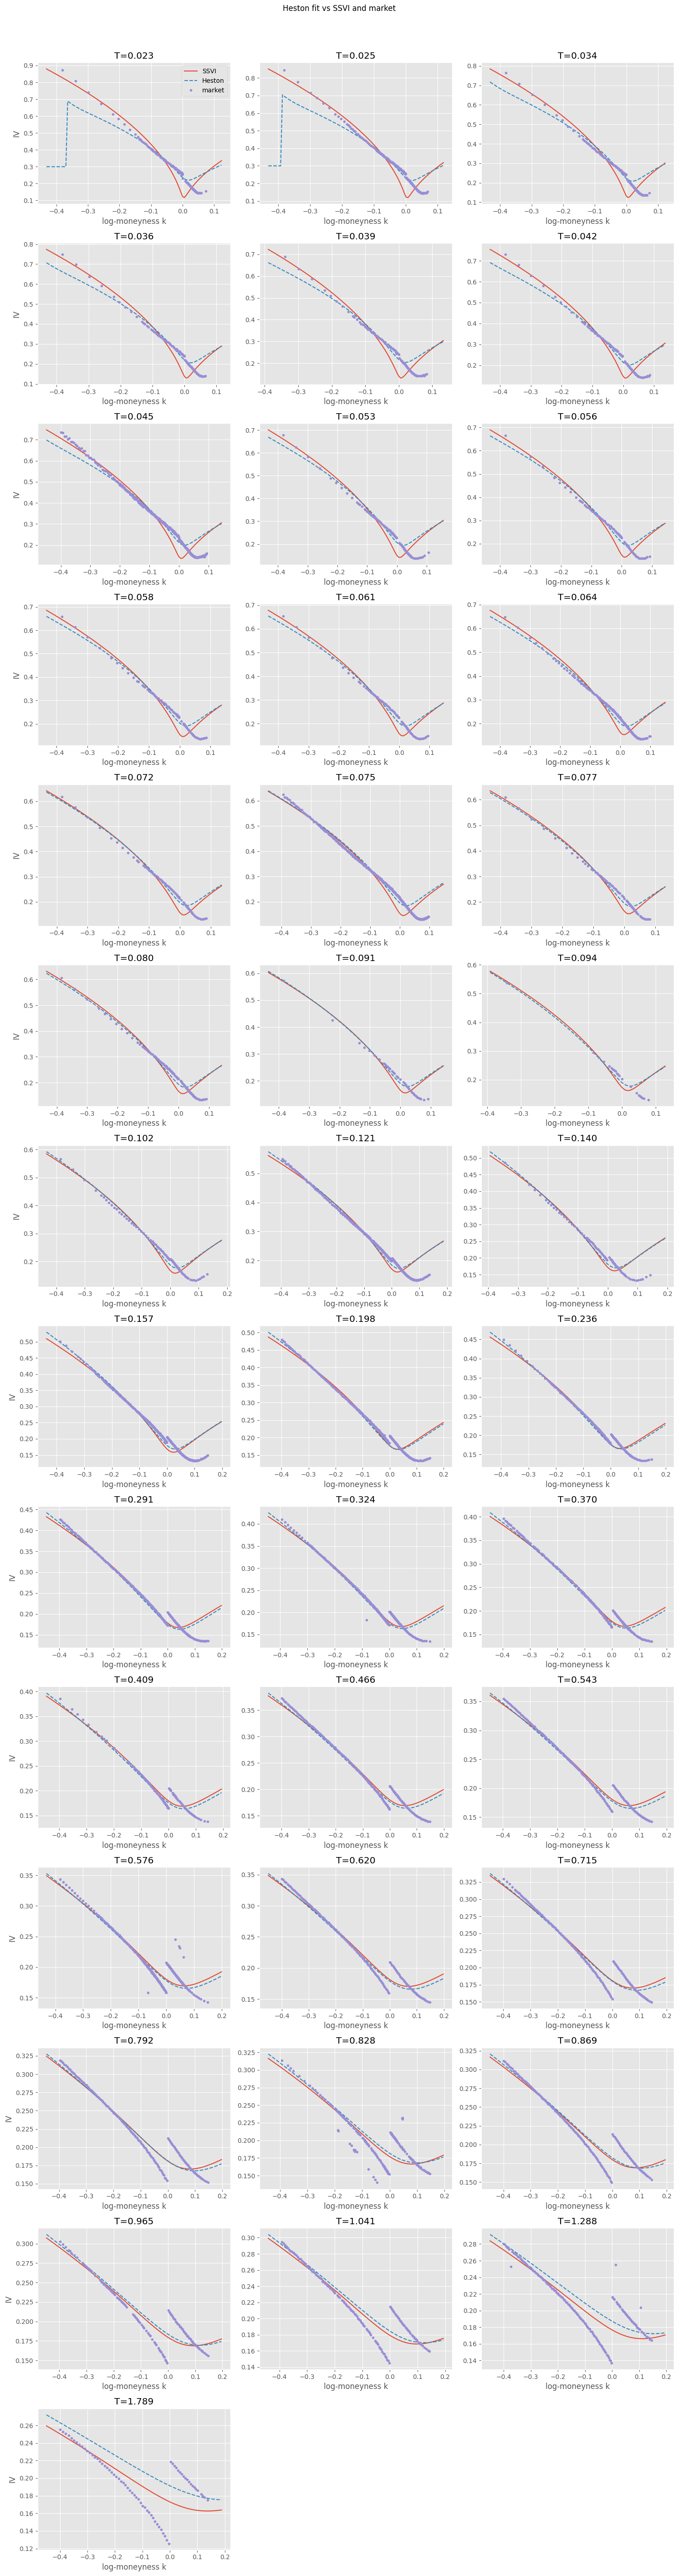

In [7]:
curve  = cppfm.FlatDiscountCurve(r)
heston = cppfm.HestonModel(spot=S0, discount_curve=curve,
                             v0=v0, kappa=kappa, vbar=vbar, sigma_v=xi, rho=rho_h)

n_slices = len(slices)
fig, axes = plt.subplots((n_slices + 2) // 3, 3,
                          figsize=(15, 4 * ((n_slices + 2) // 3)), squeeze=False)
for i, s in enumerate(slices):
    ax = axes[i // 3][i % 3]
    k_fine = np.linspace(s['k'].min() - 0.05, s['k'].max() + 0.05, 100)
    K_fine = s['F'] * np.exp(k_fine)

    heston_ivs = []
    for K in K_fine:
        try:
            price = cppfm.heston_call_price(S0, K, r, s['T'], kappa, vbar, xi, rho_h, v0)
            iv = cppfm.bs_implied_volatility(S0, K, r, s['T'], price, cppfm.OptionType.Call)
            heston_ivs.append(iv if not np.isnan(iv) else np.nan)
        except Exception:
            heston_ivs.append(np.nan)

    ssvi_ivs = [surface.implied_volatility(K, s['T']) for K in K_fine]

    ax.plot(k_fine, ssvi_ivs,   '-',  lw=1.5, label='SSVI')
    ax.plot(k_fine, heston_ivs, '--', lw=1.5, label='Heston')
    ax.plot(s['k'], s['ivs'],   'o',  ms=3,   label='market')
    ax.set_title(f"T={s['T']:.3f}")
    ax.set_xlabel('log-moneyness k')
    if i % 3 == 0: ax.set_ylabel('IV')

for j in range(i + 1, axes.size): axes.flat[j].set_visible(False)
axes[0][0].legend()
plt.suptitle('Heston fit vs SSVI and market', y=1.01)
plt.tight_layout(); plt.show()

## Leverage Function

{cite:t}`VanDerStoep2014` iteration calibrates $L(S,t)$ such that the SLV model reprices the full SSVI surface exactly.

$$dS_t = \sqrt{v_t}\,L(S_t,t)\,S_t\,dW_t^S, \qquad L^{(n)}(S,t) = \frac{\sigma_{\rm Dupire}(S,t)}{\sqrt{\mathbb{E}^{(n-1)}[v_t \mid S_t = S]}}$$

Calibrating leverage function (Van der Stoep)...
Converged in 24 iterations  |  final error: 0.000062


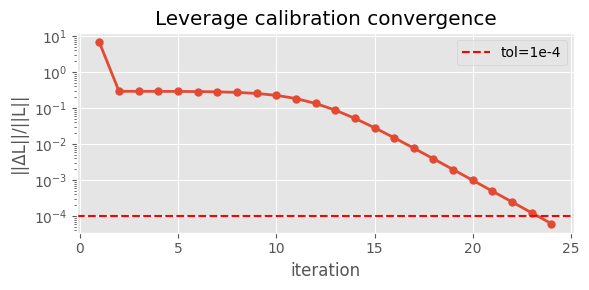

In [8]:
T_max      = maturities[-1]
n_steps    = int(T_max * 100)      # 100 steps/year — Van der Stoep (2014) setting
n_paths    = 100_000               # 100k for calibration pass
n_bins     = 20
time_steps = list(np.linspace(0, T_max, n_steps + 1))

slv_sim = cppfm.HestonSLVSimulator(
    heston,
    ssvi,          # analytical SSVI Dupire — no grid round-trip
    forwards,
    time_steps,
    num_paths=n_paths,
    num_bins=n_bins,
    seed=42
)

print("Calibrating leverage function (Van der Stoep)...")
slv_sim.calibrate_leverage(max_iters=30, tol=1e-4, damping=0.5)

errors = slv_sim.get_calibration_errors()
print(f"Converged in {len(errors)} iterations  |  final error: {errors[-1]:.6f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(range(1, len(errors) + 1), errors, 'o-', lw=2, ms=5)
ax.axhline(1e-4, color='r', ls='--', label='tol=1e-4')
ax.set_xlabel('iteration'); ax.set_ylabel('||ΔL||/||L||')
ax.set_title('Leverage calibration convergence')
ax.legend()
plt.tight_layout() 
plt.show()

In [9]:
# leverage from initial 100k-path calibration — shape is representative,
# final 200k-path recalibration below is used for actual simulation
L2_flat = np.array(slv_sim.get_leverage_grid())
S_pts   = np.array(slv_sim.get_spot_grid())
n_s     = slv_sim.get_num_spot_points()
n_t     = len(L2_flat) // n_s
L_grid  = np.sqrt(L2_flat.reshape(n_t, n_s))  # stored as L², take sqrt

# trim to ±20% around spot
mask = (S_pts > S0 * 0.80) & (S_pts < S0 * 1.20)
S_plot = S_pts[mask]
L_plot = L_grid[:, mask]
t_plot = np.linspace(0, T_max, n_t)
S_mesh, t_mesh = np.meshgrid(S_plot, t_plot)

fig = go.Figure(data=[go.Surface(x=S_mesh, y=t_mesh, z=L_plot, colorscale='RdYlGn')])
fig.update_layout(
    title='Calibrated Leverage Function L(S, t)',
    scene=dict(xaxis_title='Spot S', yaxis_title='Time t', zaxis_title='L(S,t)'),
    width=900, height=650
)
fig.show()

## Monte Carlo Paths

In [10]:
# re-calibrate leverage with more paths for better conditional expectation estimates
n_paths_final = 200_000
slv_final = cppfm.HestonSLVSimulator(
    heston,
    ssvi,
    forwards,
    time_steps,
    num_paths=n_paths_final,
    num_bins=n_bins,
    seed=123
)
slv_final.calibrate_leverage(max_iters=30, tol=1e-4, damping=0.5)

print(f"Simulating {n_paths_final:,} paths × {n_steps} steps...")
t0 = time.time()
terminal = slv_final.simulate(parallel=True)
print(f"Done in {time.time() - t0:.1f}s")

S_terminal = np.array([sv[0] for sv in terminal])
V_terminal = np.array([sv[1] for sv in terminal])
Ev_T = vbar + (v0 - vbar) * np.exp(-kappa * T_max)
print(f"S: mean={S_terminal.mean():.1f}  std={S_terminal.std():.1f}")
print(f"V: mean={V_terminal.mean():.4f}  (E[v_T]={Ev_T:.4f})")

Simulating 200,000 paths × 178 steps...
Done in 1.5s
S: mean=7224.0  std=2018.7
V: mean=0.0511  (E[v_T]=0.0501)


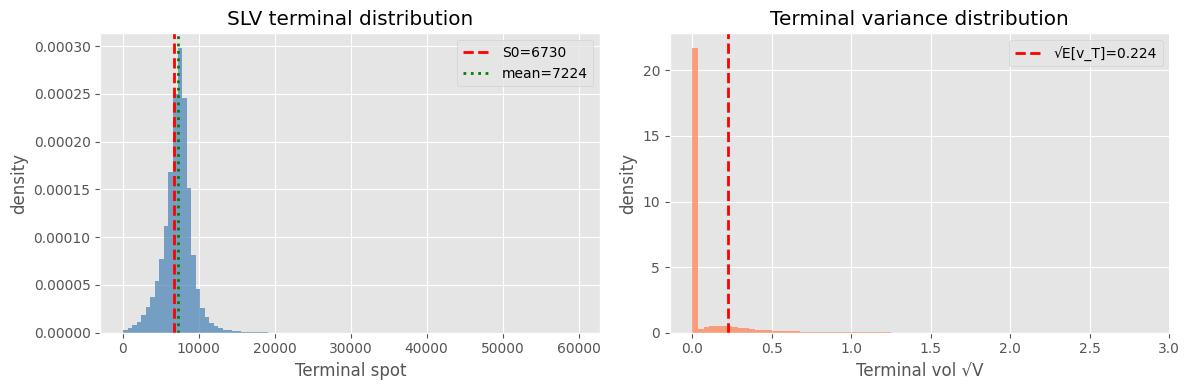

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(S_terminal, bins=100, density=True, alpha=0.7, color='steelblue')
axes[0].axvline(S0,                color='red',   ls='--', lw=2, label=f'S0={S0:.0f}')
axes[0].axvline(S_terminal.mean(), color='green', ls=':',  lw=2, label=f'mean={S_terminal.mean():.0f}')
axes[0].set_xlabel('Terminal spot'); axes[0].set_ylabel('density')
axes[0].set_title('SLV terminal distribution'); axes[0].legend()

axes[1].hist(np.sqrt(V_terminal), bins=80, density=True, alpha=0.7, color='coral')
axes[1].axvline(np.sqrt(Ev_T), color='red', ls='--', lw=2, label=f'√E[v_T]={np.sqrt(Ev_T):.3f}')
axes[1].set_xlabel('Terminal vol √V'); axes[1].set_ylabel('density')
axes[1].set_title('Terminal variance distribution'); axes[1].legend()

plt.tight_layout(); plt.show()

## Verification: does SLV reprice the surface?

Back out implied vols from simulated terminal distributions at each maturity slice. If calibration is correct, simulated IVs should track SSVI closely.

In [12]:
def implied_vol_mc(S0, K, r, T, S_terminal):
    """Invert MC call price to IV via cppfm."""
    discount = np.exp(-r * T)
    mc_price = discount * np.maximum(S_terminal - K, 0).mean()
    try:
        return cppfm.bs_implied_volatility(S0, K, r, T, mc_price, cppfm.OptionType.Call)
    except Exception:
        return np.nan  # wings won't invert cleanly

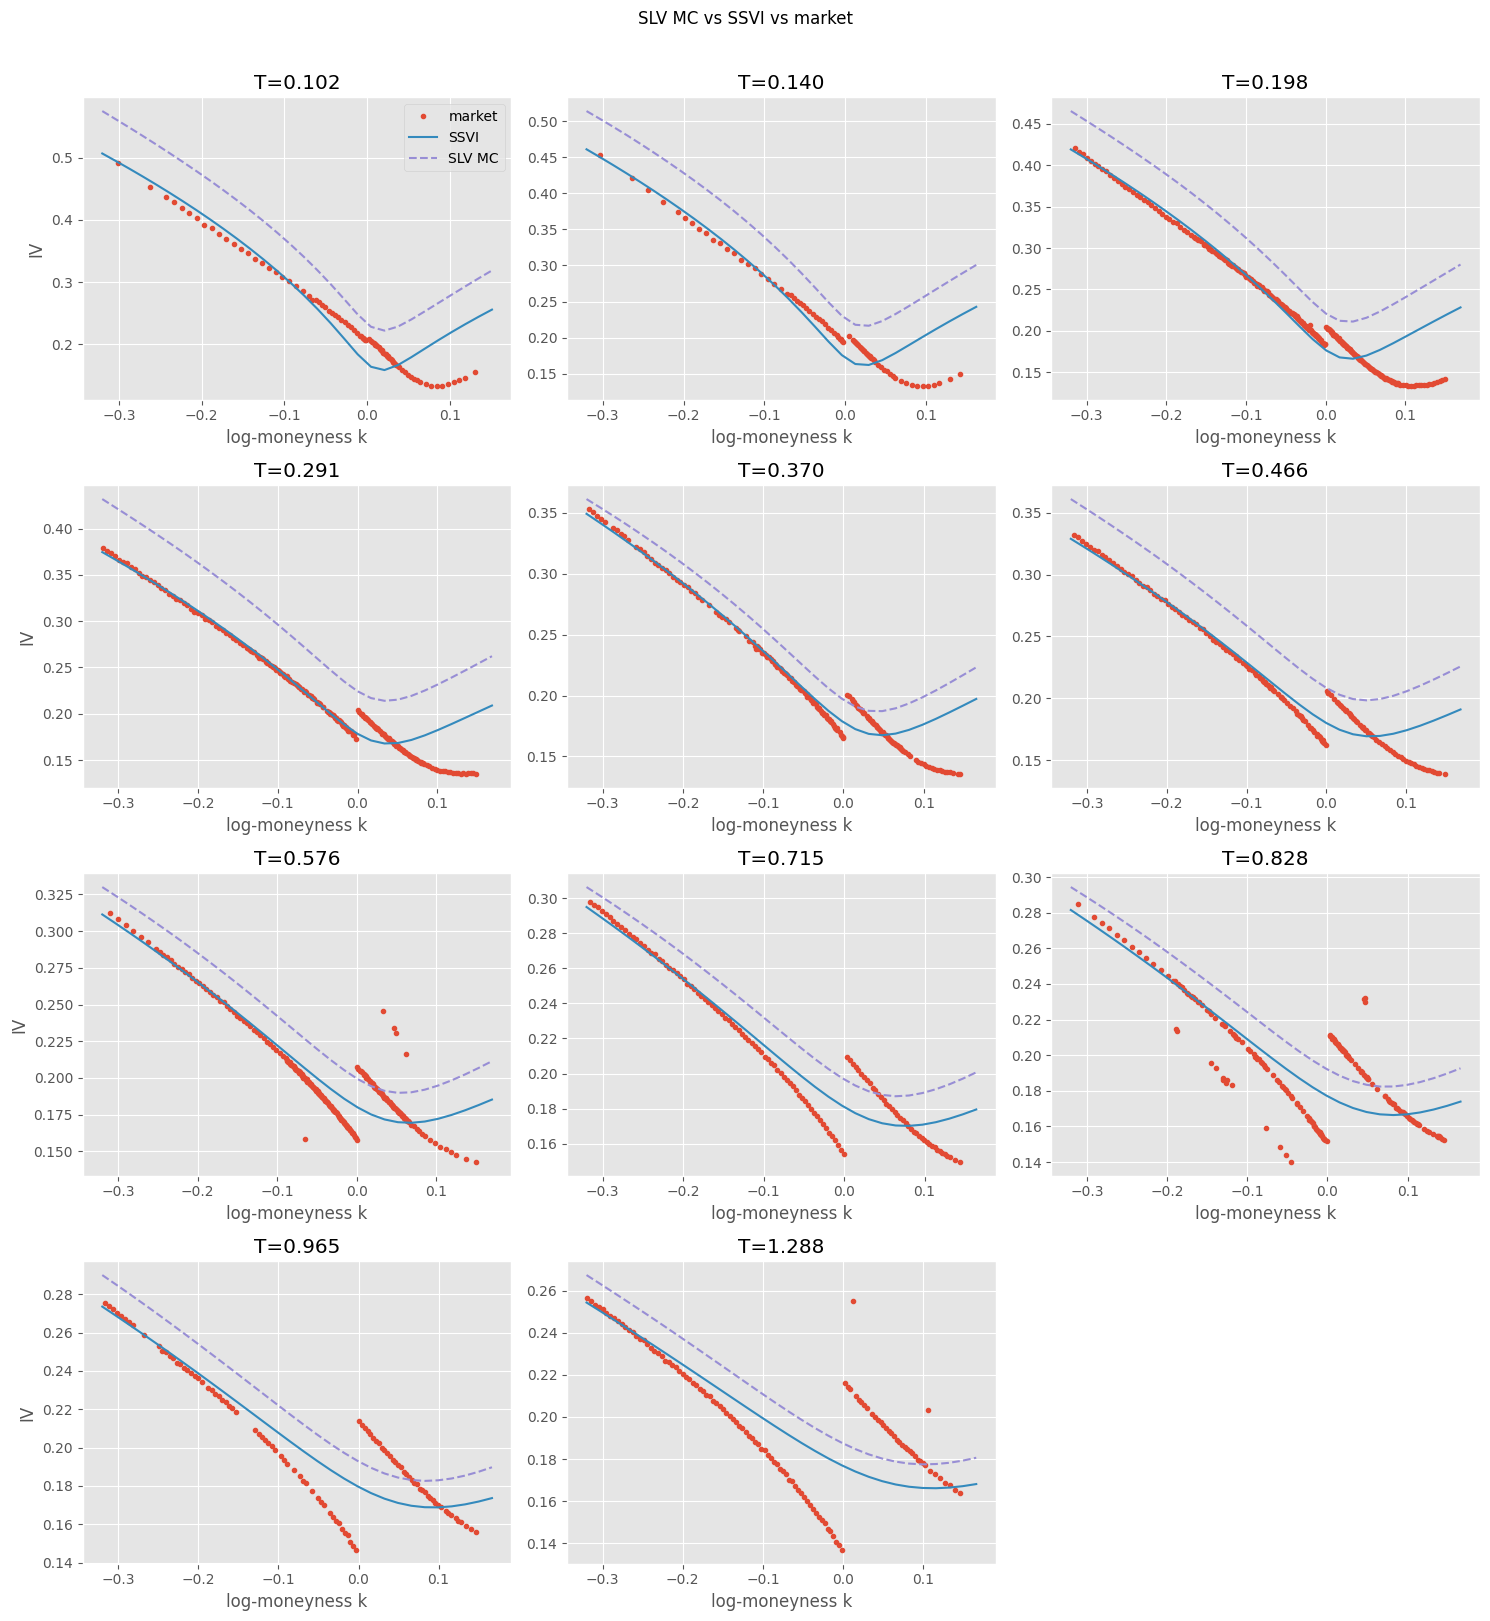

In [13]:
# verify on a subset — skip very short maturities where MC is too crude
# each slice gets its own simulator calibrated to T_i, not a single long sim
# with intermediate readouts — the leverage function depends on the time grid,
# so per-slice gives cleaner results (~2-3 min total)
verif_slices = [s for s in slices if s['T'] > 0.1]
verif_slices = verif_slices[::max(1, len(verif_slices) // 8)]  # ~8 slices

n_v = len(verif_slices)
fig, axes = plt.subplots((n_v + 2) // 3, 3,
                          figsize=(15, 4 * ((n_v + 2) // 3)), squeeze=False)
n_paths_verif = 200_000

for i, s in enumerate(verif_slices):
    T_s     = s['T']
    steps_s = max(50, int(T_s * 100))
    ts_s    = list(np.linspace(0, T_s, steps_s + 1))

    sim_s = cppfm.HestonSLVSimulator(
        heston, ssvi, forwards, ts_s,
        num_paths=n_paths_verif, num_bins=n_bins, seed=42 + i
    )
    sim_s.calibrate_leverage(max_iters=30, tol=1e-4, damping=0.5)
    term_s = sim_s.simulate(parallel=True)
    S_s    = np.array([sv[0] for sv in term_s])

    # restrict to |k| < 0.3 — MC can't reliably price deep wings
    k_lo   = max(s['k'].min(), -0.3)
    k_hi   = min(s['k'].max(),  0.3)
    k_fine = np.linspace(k_lo - 0.02, k_hi + 0.02, 30)
    K_fine   = s['F'] * np.exp(k_fine)
    ssvi_ivs = [surface.implied_volatility(K, T_s) for K in K_fine]
    mc_ivs   = [implied_vol_mc(S0, K, r, T_s, S_s) for K in K_fine]

    # market points in the same range
    k_mask = (s['k'] >= k_lo - 0.02) & (s['k'] <= k_hi + 0.02)

    ax = axes[i // 3][i % 3]
    ax.plot(s['k'][k_mask], s['ivs'][k_mask], 'o', ms=3, label='market')
    ax.plot(k_fine, ssvi_ivs, '-',  lw=1.5, label='SSVI')
    ax.plot(k_fine, mc_ivs,   '--', lw=1.5, label='SLV MC')
    ax.set_title(f"T={T_s:.3f}")
    ax.set_xlabel('log-moneyness k')
    if i % 3 == 0: ax.set_ylabel('IV')

for j in range(i + 1, axes.size): axes.flat[j].set_visible(False)
axes[0][0].legend()
plt.suptitle('SLV MC vs SSVI vs market', y=1.01)
plt.tight_layout(); plt.show()

Resolved: `HestonSLVSimulator` now takes the SSVI calibration result directly and uses the analytical Dupire local vol. The old path sampled SSVI onto a strike grid and re-derived local vol numerically, which flattened wing local vol ~2x at short maturities — the leverage function was calibrated to those too-flat targets and the SLV smile came out systematically low.